## 00_line_chart.ipynb

In [1]:
import pandas as pd
import sqlite3

## Run a query that gets the datetime from the pageviews table, selecting only users and not admins.

In [2]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

In [3]:
query = """
        SELECT *
        FROM pageviews
        WHERE uid NOT LIKE '%admin%';
        """

pageviews = pd.read_sql(query, conn, parse_dates=['datetime'])

## Using Pandas, create a new dataframe where the visits are counted and grouped by date.

In [4]:
pageviews['date'] = pd.to_datetime(pageviews['datetime']).dt.date
views_per_day = pageviews.groupby('date').size().reset_index(name='views')

In [5]:
views_per_day

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


## Using the Pandas method .plot(), create a graph.

<Axes: title={'center': 'Views per Day'}, xlabel='date'>

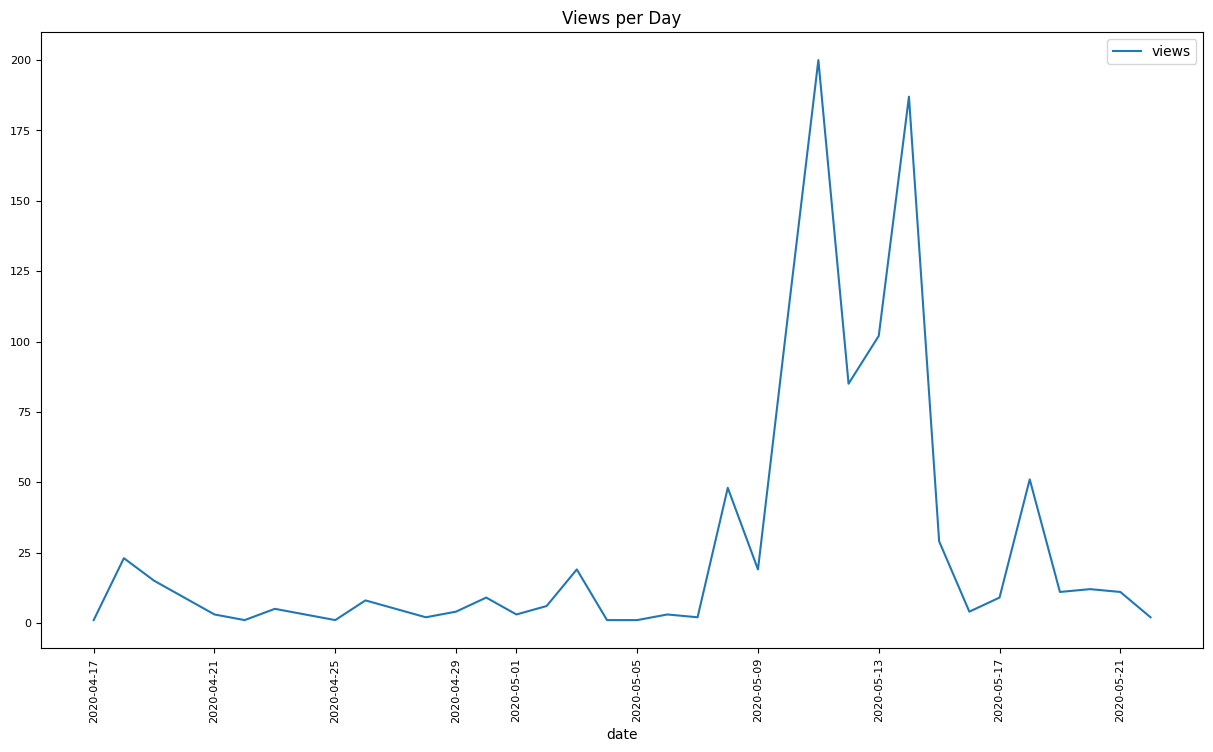

In [6]:
views_per_day.plot(x='date', y='views', kind='line', fontsize=8, figsize=(15,8), title='Views per Day', rot=90)

In [7]:
conn.close()